In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target



## TRAIN THE DATA

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Step 2: Gradient Descent Implementation

In [8]:
m, n = X_train.shape
weights = np.zeros(n)
bias = 0
learning_rate = 0.01
iterations = 200
losses = []


In [9]:
for _ in range(iterations):
    y_pred = X_train.dot(weights) + bias
    error = y_pred - y_train

    loss = np.mean(error ** 2)
    losses.append(loss)

    dw = (2/m) * X_train.T.dot(error)
    db = (2/m) * np.sum(error)

    weights -= learning_rate * dw
    bias -= learning_rate * db


# TASK 5: Plot Error vs Iterations (Convergence Curve)

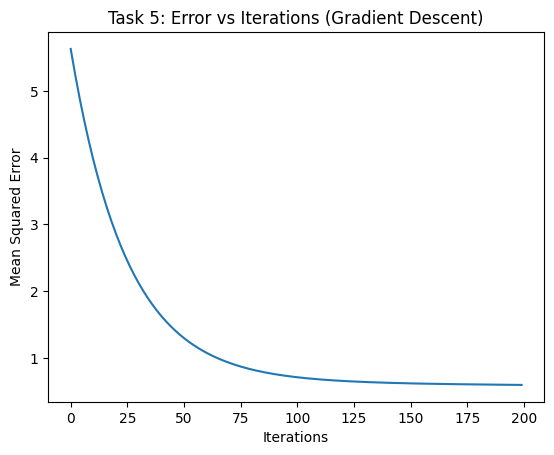

In [10]:
# Visualize how fast and how smoothly the model learns.
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.title("Task 5: Error vs Iterations (Gradient Descent)")
plt.show()


# TASK 6: Apply L2 Regularization to Gradient Descent Model

In [11]:
# Reduce overfitting by penalizing large weights.
# Loss=MSE+λ∑w2
lambda_ = 0.1
weights_l2 = np.zeros(n)
bias_l2 = 0
losses_l2 = []

for _ in range(iterations):
    y_pred = X_train.dot(weights_l2) + bias_l2
    error = y_pred - y_train

    loss = np.mean(error ** 2) + lambda_ * np.sum(weights_l2 ** 2)
    losses_l2.append(loss)

    dw = (2/m) * X_train.T.dot(error) + 2 * lambda_ * weights_l2
    db = (2/m) * np.sum(error)

    weights_l2 -= learning_rate * dw
    bias_l2 -= learning_rate * db


# TASK 7: Compare With vs Without Regularization

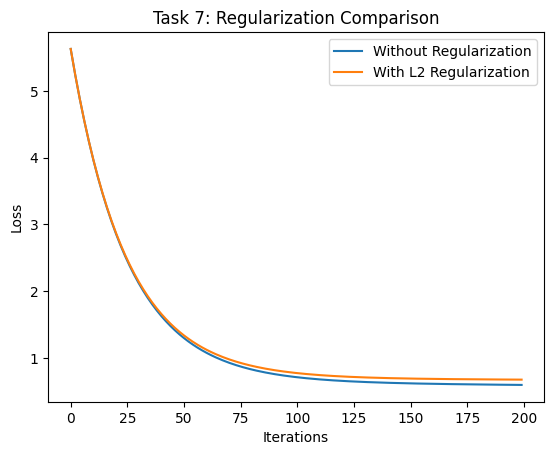

In [12]:
plt.plot(losses, label="Without Regularization")
plt.plot(losses_l2, label="With L2 Regularization")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Task 7: Regularization Comparison")
plt.legend()
plt.show()


# TASK 8: Analyze Convergence Behavior & Coefficient Stability

      Feature  Weight (No Reg)  Weight (L2 Reg)
0      MedInc         0.774647         0.706629
1    HouseAge         0.193371         0.172854
2    AveRooms         0.004402         0.018666
3   AveBedrms         0.004947        -0.006802
4  Population         0.015964         0.010889
5    AveOccup        -0.043003        -0.037980
6    Latitude        -0.280631        -0.241461
7   Longitude        -0.235861        -0.197206


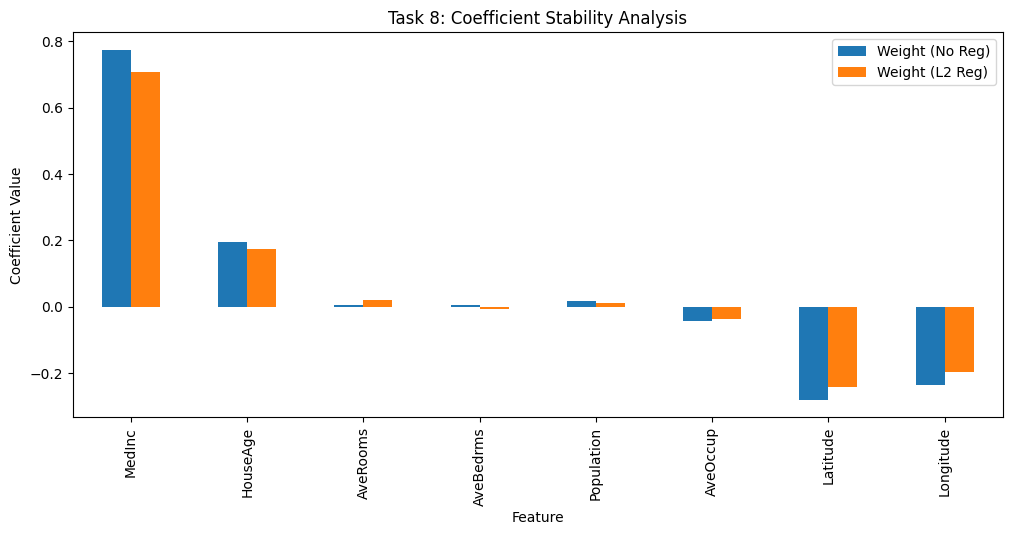

In [13]:
# Study how regularization affects weights.
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Weight (No Reg)": weights,
    "Weight (L2 Reg)": weights_l2
})

print(coef_df)

coef_df.set_index("Feature").plot(kind="bar", figsize=(12, 5))
plt.ylabel("Coefficient Value")
plt.title("Task 8: Coefficient Stability Analysis")
plt.show()

